# Классификация снимков КТ грудной клетки с помощью свёрточных нейронных сетей

<a id=content></a>
## Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
<br>[<b>Шаг 1. Загрузка данных и получение общей информации</b>](#1)
<br>[1.1. Загрузка библиотек и google диска](#1.1.)
<br>[1.2. Монтирование google диска](#1.2.)
<br>[<b>Шаг 2. Подготовка данных</b>](#2)
<br>[2.1. Создание датасета с изображениями](#2.1.)
<br>[2.2. Визуализация данных](#2.2.)
<br>[2.3. Конфигурирование датасета для улучшения производительности](#2.3.)
<br>[2.4. Нормирование данных](#2.4.)
<br>[<b>Шаг 3. Создание базовой модели</b>](#3)
<br>[3.1. Создание базовой модели](#3.1.)
<br>[3.2. Отладка базовой модели](#3.2.)
<br>[3.3. Структура базовой модели](#3.3.)
<br>[3.4. Обучение базовой модели](#3.4.)
<br>[3.5. Визуализация результатов базовой модели классификации](#3.5.)
<br>[<b>Шаг 4. Улучшение параметров модели классификации</b>](#4)
<br>[4.1. Переобучение (Overfitting)](#4.1.)
<br>[4.2. Расширение набора данных (Data augmentation)](#4.2.)
<br>[4.3. Исключение из обучения (Dropout)](#4.3.)
<br>[4.4. Подбор оптимальной архитектуры и гиперпараметров](#4.4.)
<br>[4.5. Отладка и обучение улучшенной модели классификации](#4.5.)
<br>[4.6. Визуализация результатов классификации улучшенной модели классификации](#4.6.)
<br>[4.7. Предсказание улучшенной модели классификации на новых данных](#4.6.)
<br>[<b>Вывод</b>](#5)
<br>[<b>Источники и литература</b>](#6)

<a id=descr_proj></a>
## Описание проекта
Свёрточные нейронные сети (CNN) — это специализированный алгоритм глубокого обучения, созданный для автоматического распознавания и анализа визуальных данных (изображений, видео, 3D-сканов). Их главная особенность — способность самостоятельно извлекать пространственные иерархии признаков: от простых линий и контрастов до сложных структур и целых объектов, игнорируя при этом незначительные искажения и шумы. Основные задачи, которые они решают:
*   **Классификация изображений:** определение категории объекта на снимке (например, «норма» или «патология»).
*   **Детекция объектов:** поиск и локализация предметов на изображении с помощью ограничивающих рамок (например, поиск автомобилей на дороге).
*   **Семантическая и инстанс-сегментация:** попиксельное разделение изображения на классы или выделение конкретных экземпляров объектов (например, точное обведение контуров опухоли).
*   **Распознавание образов:** биометрия (лица, отпечатки), OCR (чтение текста), анализ жестов.

В медицине свёрточные сети применяются прежде всего для преодоления ограничений человеческой физиологии при работе с огромными массивами сложных визуальных данных. Врачи-диагносты (рентгенологи, патологи) сталкиваются с колоссальной нагрузкой и усталостью, из-за чего риск пропустить микроскопические аномалии или допустить ошибку возрастает. CNN выступают в роли неутомимого «второго мнения»: они обрабатывают снимки за доли секунды, обладают идеальной воспроизводимостью и выявляют скрытые, неочевидные для человеческого глаза паттерны. Это критически важно для ранней диагностики заболеваний (например, онкологии), когда симптомы ещё не проявились, а шансы на успешное лечение максимальны.

Свёрточные нейронные сети используются для анализа рентгеновских снимков, МРТ, КТ, УЗИ и гистологических препаратов. Например, алгоритмы сегментируют опухоли на КТ, точно измеряя их объем для оценки динамики роста, ищут признаки пневмонии или скрытые переломы на рентгене, а также выявляют микроскопические метастазы на цифровых слайдах биопсии. В офтальмологии CNN анализируют снимки глазного дна для диагностики диабетической ретинопатии, а в хирургии — помогают автоматически строить 3D-модели органов и сосудов для точного планирования сложных операций.

**Постановка задачи:** повысить точность классификации снимков, изменяя базовые значения параметров в пунктах [3.1. Создание базовой модели](#3.1.), [3.2. Отладка базовой модели](#3.2.) и [3.4. Обучение базовой модели](#3.4.) Jupiter Notebook. Интерпретировать полученный результат.

<a id=descr_data></a>
## Описание данных
В рамках данной практической работы в обработку поступил датасет снимков компьютерной томографии (КТ) грудной клетки с подтверждённым диагнозом SARS-CoV-2 (COVID-19) и здоровых пациентов. Необходимо классифицировать медицинские изображения, разделив их на два класса. Для решения этой задачи используется набор данных из 7560 снимков КТ в градациях серого цвета, который имеет чёткую структуру из двух директорий внутри папки coronacases/: CT_Covid-19/ и CT_Non_Covid-19/. Такая организация данных представляет собой классическую постановку задачи бинарной классификации, идеально подходящую для обучения сверточных нейронных сетей распознаванию специфических паттернов поражения лёгких.

**Что критически важно знать об этом типе данных:**
<br><input type="checkbox" checked disabled>*Что такое «градации серого» в КТ:* изначально компьютерная томография — это 3D-массив данных, где значения пикселей измеряются в единицах Хаунсфилда (HU), отражающих плотность тканей. То, что мы видим как 2D-снимки в оттенках серого (зачастую в форматах PNG или JPG), — это, вероятнее всего, уже извлечённые аксиальные срезы, к которым применено «оконное преобразование». Это стандартная предобработка, которая сужает диапазон плотностей, чтобы визуально выделить именно легочную ткань и сделать патологические изменения контрастными для нейросети.
<br><input type="checkbox" checked disabled>*Что именно будет искать модель:* в директории `CT_Covid-19` алгоритм будет учиться распознавать характерные радиологические маркеры: двусторонние затемнения по типу «матового стекла», консолидации и их типичное периферическое расположение в нижних долях лёгких. В папке `CT_Non_Covid-19` находятся либо снимки здоровой легочной ткани, либо изображения с другими патологиями (например, бактериальная пневмония), которые не имеют этой специфической вирусной картины.

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

<a id=1.1.></a>
### 1.1. Загрузка библиотек и google диска

In [1]:
# установка библиотеки tensorflow
!pip install tensorflow pillow matplotlib numpy

# импорт библиотек
import pathlib
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
import PIL

print('Версия TensorFlow:', tf.__version__)

Версия TensorFlow: 2.20.0


<a id=1.2.></a>
### 1.2. Монтирование google диска

In [2]:
# загрузка датасета на google диск и монтирование содержимого
drive.mount('/content/drive', force_remount=True)
coronacases_dir = pathlib.Path('/content/drive/MyDrive/coronacases')
print('Директория с датасетом:', coronacases_dir)

Mounted at /content/drive
Директория с датасетом: /content/drive/MyDrive/coronacases


In [3]:
# посчитаем количество изображений
image_count = len(list(coronacases_dir.glob('*/*.png')))
print(image_count)

7560


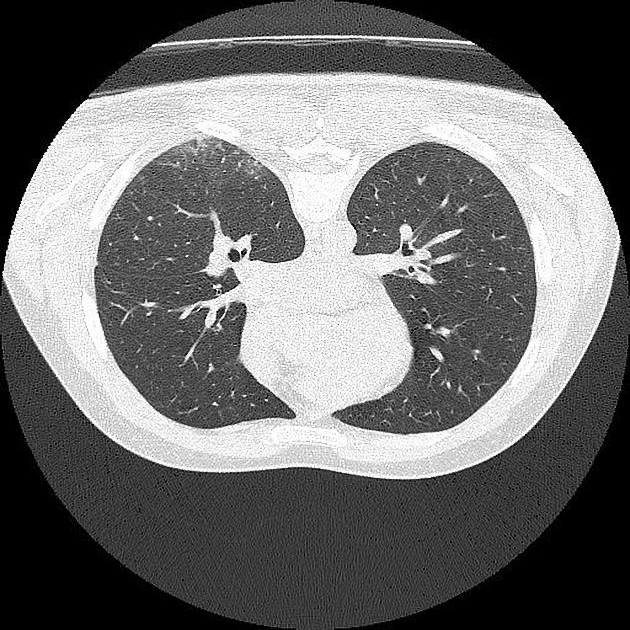

In [4]:
# пример изображения из директории с подтверждённым диагнозом Covid-19
infected = list(coronacases_dir.glob('CT_Covid-19/*'))
PIL.Image.open(str(infected[64]))

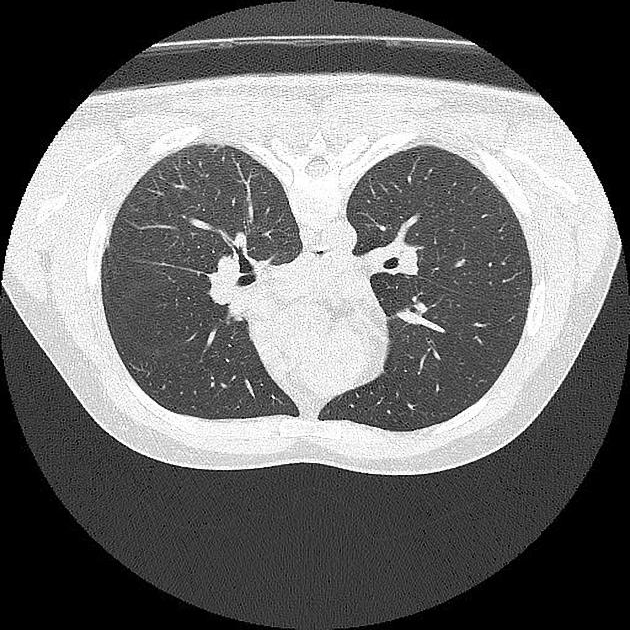

In [5]:
# пример изображения из директории с подтверждённым диагнозом Covid-19
PIL.Image.open(str(infected[78]))

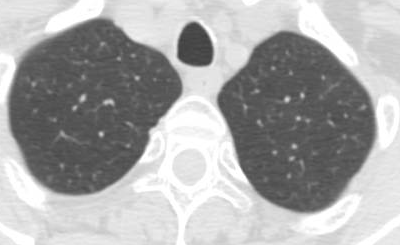

In [6]:
# пример изображения из директории снимков здоровых пациентов
not_infected = list(coronacases_dir.glob('CT_Non_Covid-19/*'))
PIL.Image.open(str(not_infected[29]))

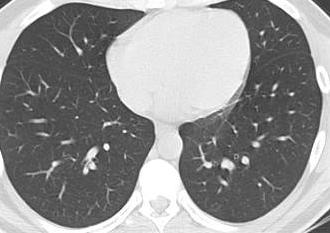

In [7]:
# пример изображения из директории снимков здоровых пациентов
PIL.Image.open(str(not_infected[38]))

<a id=2></a>
## Шаг 2. Подготовка данных

<a id=2.1.></a>
### 2.1. Создание датасета с изображениями

В медицинской визуализации, и в частности при анализе компьютерной томографии (КТ), существуют строгие стандарты качества, обусловленные необходимостью сохранения тонких пространственных и текстурных особенностей анатомических структур. Исходные КТ-срезы в формате DICOM традиционно имеют разрешение 512×512 пикселей, что критически важно для визуализации микроскопических патологических маркеров, таких как участки консолидации или симптом «матового стекла» (ground-glass opacities), характерных для пневмонии и COVID-19. Использование разрешения 180×180 пикселей является диагностически недостаточным, так как агрессивное даунсэмплирование (уменьшение размера) приводит к необратимой потере высокочастотных деталей, интерполяционным артефактам и сглаживанию границ между здоровой и пораженной тканью, из-за чего мелкие очаги патологии просто сливаются с фоновым шумом. Минимально обоснованным компромиссом между вычислительной эффективностью и сохранением клинической значимости данных считается разрешение 224×224 (или 256×256) пикселей: оно не только соответствует стандартным входным размерам современных предобученных сверточных архитектур (например, ResNet или MobileNet), но и обеспечивает нейросети достаточный уровень детализации для надежного извлечения признаков, минимизируя риск ложноотрицательных заключений на ранних стадиях заболевания.

Загрузить датасет `tf.data.Dataset` с изображениями с диска можно с помощью утилиты[image_dataset_from_directory](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory). Также можно создать загрузчик изображений с нуля, используя [load images](https://www.tensorflow.org/tutorials/load_data/images).

In [8]:
# установим базовые гиперпараметры для подготовки и загрузки набора данных с изображениями

# количество изображений, которые модель будет обрабатывать за один шаг, то есть размер батча (пакета)
batch_size = 32

# целевая высота изображения в пикселях (до этого размера будут изменены все картинки)
img_height = 224

# целевая ширина изображения в пикселях (до этого размера будут изменены все картинки)
img_width = 224

In [9]:
# создание тренировочного датасета в размере 80% от оригинального датасета
# загружаем изображения из директории с использованием keras.preprocessing и создаём датасет для обучения
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  coronacases_dir,          # задём путь к корневой папке с исходными изображениями
  validation_split=0.2,     # тренировочный датасет в размере 80% от оригинальных данных, оставшиеся 20% для валидации (проверки)
  subset="training",        # указываем, что загружаем именно обучающую выборку (отделённые 80%)
  seed=123,                 # фиксируем случайное зерно, чтобы разбиение было одинаковым при каждом запуске
  image_size=(img_height, img_width), # приводим все изображения к единому размеру (180x180), которые мы задали на предыдущем шаге
  batch_size=batch_size)    # объединяем изображения в батчи (пакеты) по 32 штуки для подачи в модель, задан на предыдущем шаге

Found 7561 files belonging to 2 classes.
Using 6049 files for training.


In [10]:
# создание валидационного (проверочного) датасета в размере 20% от оригинального датасета
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  coronacases_dir,          # тот же путь к корневой папке с исходными снимками
  validation_split=0.2,     # доля данных для валидации (проверки) = 20%, как и при создании обучающей выборки
  subset="validation",      # указываем, что загружаем именно валидационную (проверочную) валидационную часть
  seed=123,                 # обязательно то же зерно, чтобы в train и val не попали одни и те же снимки
  image_size=(img_height, img_width), # единый размер изображений (180x180)
  batch_size=batch_size)    # размер батча (пакета) для подачи в модель

Found 7561 files belonging to 2 classes.
Using 1512 files for validation.


In [11]:
# получим список названий классов (имён подпапок), которые Keras определил автоматически
# эти классы соответствуют именам директорий и отсортированы в алфавитном порядке
class_names = train_ds.class_names

# выводим эти названия на экран, чтобы увидеть, какие категории будет предсказывать модель
print(class_names)

['CT_Covid-19', 'CT_Non_Covid-19']


<a id=2.2.></a>
### 2.2. Визуализация данных

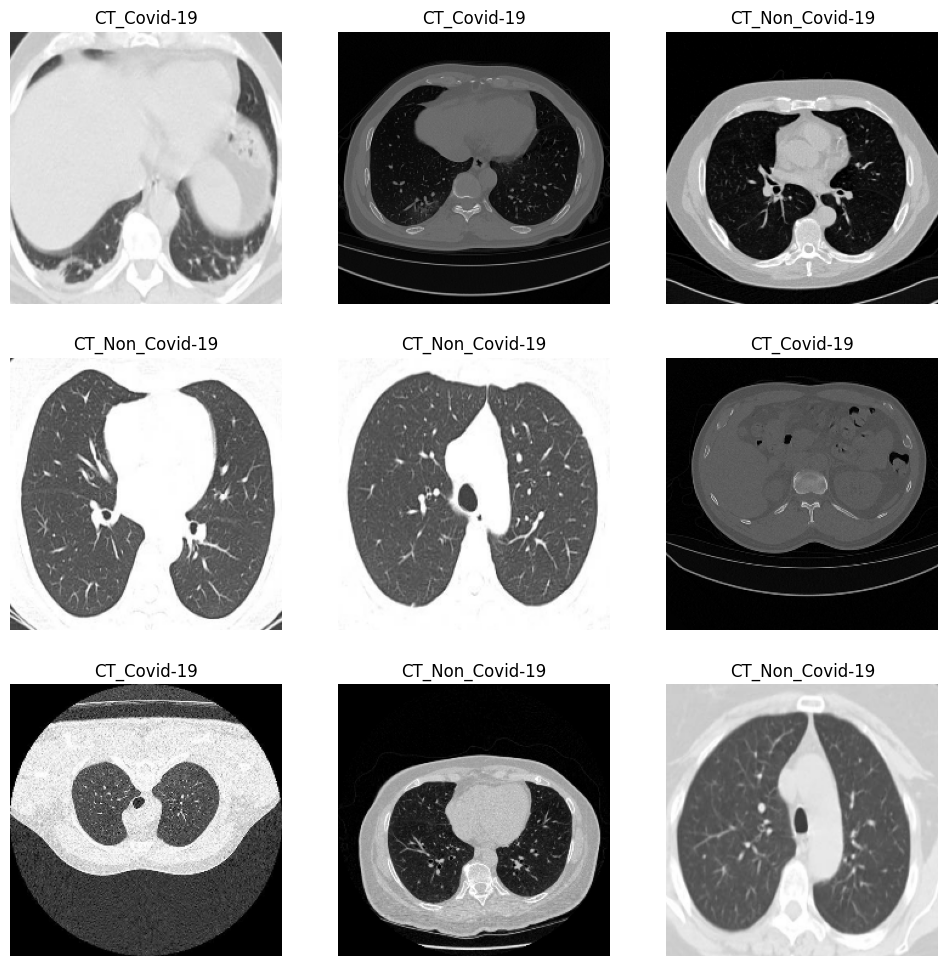

In [12]:
# первые 9 изображений из тренировочного датасета
plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1): # берём ровно один батч (пакет) из обучающего датасета
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)  # создаём сетку 3x3 и выбираем ячейку (i + 1) для текущего изображения
    plt.imshow(images[i].numpy().astype("uint8")) # метод .numpy() применён к тензорам  размерности, чтобы преобразовать их в numpy.ndarray
    plt.title(class_names[labels[i]]) # в качестве заголовка указываем название класса, к которому относится изображение
    plt.axis("off")

Проведём извлечение первого батча (пакета) данных из обучающего датасета и выведем на экран размеры (формы) тензоров с изображениями и их метками. Это стандартная проверка, чтобы убедиться, что данные имеют правильную размерность (количество картинок, высота, ширина, цветовые каналы) перед подачей в нейросеть.

In [13]:
# проходим по первому батчу обучающего датасета
for image_batch, labels_batch in train_ds:

  # выводим размерность тензора с изображениями: (размер батча, высота, ширина, каналы) -> (32, 224, 224, 3)
  print(image_batch.shape)

  # выводим размерность тензора с метками: (количество меток в батче) -> (32,)
  print(labels_batch.shape)

  # прерываем цикл после первой итерации, чтобы посмотреть размеры только одного батча
  break

(32, 224, 224, 3)
(32,)


<a id=2.3.></a>
### 2.3. Конфигурирование датасета для улучшения производительности

Следует обязательно использовать буферизованную предварительную выборку, чтобы мы могли читать данные с диска без блокировки ввода/вывода. Оптимизируем конвейер загрузки данных (`data pipeline`). Он значительно ускоряет обучение, кешируя данные в оперативной памяти (чтобы не читать их с диска повторно), перемешивая обучающую выборку и заранее подготавливая следующие пакеты данных, чтобы процессор и видеокарта не простаивали в ожидании.

Вот 2 важных метода, которые мы должны использовать при загрузке данных:
<br><input type="checkbox" checked disabled> `Dataset.cache()` сохраняет изображения в памяти после их загрузки с диска в течение первой эпохи. Это гарантирует, что загрузка данных не станет узким местом при обучении нашей модели. Если набор данных слишком большой и не помещается в память, мы также можем использовать этот метод для создания дискового кэша.
<br><input type="checkbox" checked disabled> `Dataset.prefetch()` перекрывает предварительную обработку данных и выполнение модели во время обучения за счёт предварительной выборки.

In [14]:
# сохраняем в кэше данные тренировочного и валидационного (проверочного) датасетов
# специальная константа, позволяющая TensorFlow автоматически подбирать оптимальные параметры для ускорения работы
AUTOTUNE = tf.data.experimental.AUTOTUNE

# автоматическая оптимизация обучающего датасета:
# cache() - кеширует данные в оперативной памяти, чтобы не читать их с диска в каждой эпохе
# shuffle(1000) - перемешивает выборку (буфер 1000), чтобы модель не училась на порядке картинок
# prefetch() - заранее готовит следующие батчи в фоновом режиме, пока модель обрабатывает текущий
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

# автоматическая оптимизация валидационного (проверочного) датасета (перемешивание здесь не требуется):
# cache() - кеширует данные в оперативной памяти для быстрого доступа
# prefetch() - заранее готовит следующие батчи для ускорения валидации
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

<a id=2.4.></a>
### 2.4. Нормирование данных

Значения канала RGB находятся в диапазоне `[0, 255]`. Это не идеально для нейронной сети, поэтому нам необходимо стремиться к тому, чтобы входные значения были небольшими. Мы нормализуем значения, чтобы они находились в диапазоне `[0, 1]`, для этого используем слой `Rescaling`. Существует 2 способа использовать слой `Rescaling`:

1) можно применить его к набору данных, вызвав метод `map`,
2) можно включить слой непосредственно в модель, что упростит развёртывание.

In [15]:
# создаём слой для нормализации: он будет проводить данные из диапазона [0, 255] к диапазону [0, 1]
normalization_layer = layers.Rescaling(1./255)

# применяем этот слой Rescaling ко всем изображениям (x) в датасете, оставляя их метки (y) без изменений
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

# проверка результатов нормализации: извлекаем первый батч из обновленного датасета
image_batch, labels_batch = next(iter(normalized_ds))

# берём самое первое изображение из этого батча
first_image = image_batch[0]

# проверяем, что значения пикселей теперь лежат в диапазоне [0, 1]
# выводим минимальное и максимальное значения по всем каналам RGB (должно получиться 0.0 и 1.0)
print(np.min(first_image), np.max(first_image))

0.20478967 1.0


Примечание: ранее мы изменяли размер изображений используя аргумент `image_size` метода `image_dataset_from_directory`. Если есть потребность включить изменения размера в модель, можно использовать слой [Resizing](https://www.tensorflow.org/api_docs/python/tf/keras/layers/experimental/preprocessing/Resizing).

<a id=3></a>
## Шаг 3. Создание базовой модели

<a id=3.1.></a>
### 3.1. Создание базовой модели свёрточной нейронной сети

Для успешного решения задачи классификации медицинских изображений с помощью нейронных сетей на этапе проектирования необходимо четко определить несколько фундаментальных аспектов:

- **I.** структуру нейронной сети (архитектуру);
- **II.** способы оптимизации алгоритма градиентного спуска;
- **III.** критерии оценки качества модели (метрики);
- **IV.** способ формирования выборки для валидации из обучающего множества.

Ниже каждый из пунктов рассматривается последовательно.

---

**I. Структура нейронной сети (архитектура)**

В данном разделе мы детально рассматриваем первый пункт — проектирование архитектуры базовой сверточной нейронной сети (`CNN`).

Архитектура базовой `CNN` для задачи бинарной классификации (`Covid` / `non-Covid`) строится по классическому принципу: блок извлечения визуальных признаков (свёрточная база) и блок итоговой классификации (полносвязные слои). Обращаем внимание, что создание данной модели преследует учебные цели демонстрации стандартных, методологически верных подходов к построению CNN. Достижение предельной точности реализовано в [пункте 4.4.](#4.4.) настоящей лабораторной работы.

**Входной слой и нормализация.** Сеть ожидает входные данные: изображения фиксированного размера 224×224 пикселя с 3 цветовыми каналами (`RGB`), что явно задается параметром `shape=(224, 224, 3)`. Важным архитектурным решением является то, что нормализация встроена прямо в модель как самый первый слой (`layers.Rescaling(1./255)`). Значения пикселей приводятся к диапазону `[0, 1]` делением на 255. Это критически важно для стабильной и быстрой сходимости градиентного спуска, так как предотвращает численную нестабильность на первых этапах обучения.

**Блок извлечения признаков** — это само сердце модели, в котором чередуются свёрточные слои (`Conv2D`) и слои подвыборки (`MaxPooling2D`). Архитектура построена по принципу иерархического усложнения признаков:

- *Первый блок (16 фильтров 3x3):* Извлечение базовых, низкоразмерных визуальных признаков. На этом этапе сеть учится находить простые паттерны: границы, градиенты, базовые текстуры тканей.
- *Второй блок (32 фильтра 3x3):* Поиск более сложных и крупных паттернов. Сеть комбинирует базовые линии, выявляя более сложные структуры.
- *Третий блок (64 фильтра 3x3):* Выявление высокоуровневых абстрактных признаков, специфичных для медицинских снимков (например, контуры зон «матового стекла», уплотнения в периферических отделах легких).

Использование параметра `padding='same'` во всех свёрточных слоях позволяет сохранять пространственные размеры карт признаков. После каждого свёрточного слоя применяется `MaxPooling2D`. Этот слой уменьшает размерность карты признаков в 2 раза, что снижает вычислительную сложность, контролирует переобучение и обеспечивает инвариантность модели к небольшим сдвигам паттернов на снимке.

**Роль функции активации ReLU.** Во всех скрытых слоях (как свёрточных, так и полносвязных) используется функция активации `relu` (Rectified Linear Unit — выпрямленная линейная функция). Если говорить просто, это математическое правило, которое применяется к каждому нейрону после того, как слой выполнил свои вычисления: если число положительное (> 0), оно остается без изменений, если число отрицательное (<= 0), оно превращается в ноль.

Без функций активации нейронная сеть была бы просто набором линейных уравнений. Свёртка и полносвязный слой — это, по сути, умножение на веса и прибавление смещения. Математически несколько таких линейных операций всё равно свернутся в одно большое линейное уравнение. Линейная модель умеет проводить только прямые линии, но граница между «здоровым лёгким» и «лёгким с матовым стеклом» на КТ — это сложная, нелинейная зависимость. ReLU вносит в сеть нелинейность, «изгибая» прямые линии и позволяя сети аппроксимировать любые сложные паттерны.

Ранее часто использовалась функция `Sigmoid`, сжимающая числа в диапазон [0, 1], но у неё были критические недостатки, которые `ReLU` решает идеально:

- *Проблема затухающего градиента:* При обратном распространении ошибки `Sigmoid` для крайних значений выдавала производную, близкую к нулю. Градиент «затухал», и сеть переставала учиться. У `ReLU` производная для положительных чисел равна ровно 1. Градиент течёт свободно, сеть обучается в разы быстрее.
- *Вычислительная дешевизна:* `Sigmoid` требует вычисления экспоненты. `ReLU` — это простая проверка условия, которая выполняется молниеносно.
- *Разреженность (Sparsity):* Обнуляя отрицательные значения, `ReLU` заставляет часть нейронов «засыпать». Это делает сеть более эффективной, заставляя её выделять только самые важные признаки и игнорировать шум.

Как это работает в контексте КТ-снимков: когда свёрточный фильтр сканирует снимок, он вычисляет, насколько участок изображения похож на искомый паттерн. Если фильтр нашел что-то похожее на «матовое стекло», он выдаст положительное число, и `ReLU` пропустит его дальше. Если фильтр наткнулся на шум или обычную ткань, он может выдать отрицательное число. `ReLU` превратит его в 0, фактически сказав: «Здесь нет полезного признака, игнорируем». Таким образом, ReLU — это «золотой стандарт» для скрытых слоев.

**Блок классификации (полносвязные слои).** После того как свёрточная база сформировала многомерное представление изображения, необходимо перевести его в формат для принятия решения:

- `layers.Flatten()`: «Распрямляет» 3D-карты признаков в одномерный вектор.
- `layers.Dense(128, activation='relu')`: Скрытый полносвязный слой из 128 нейронов. Выступает в роли промежуточного классификатора, комбинируя извлеченные признаки.
- `layers.Dense(num_classes)`: Выходной слой, содержащий 2 нейрона (по числу классов).

**Выходной слой и функция потерь.** В представленной архитектуре выходной слой состоит из 2 нейронов без явной функции активации, что означает выдачу «сырых логитов» (ненормализованных чисел). Для бинарной классификации исторически часто используют 1 нейрон с сигмоидой: `Dense(1, activation='sigmoid')`. Однако современный подход (используемый в данном коде) с двумя нейронами без активации численно более стабилен при обучении. Важно понимать, что выбор активации выходного слоя диктует функцию потерь (loss) при компиляции модели:

- Если используется `Dense(1)` с `sigmoid` → `loss='binary_crossentropy'`.
- Если используется `Dense(2)` без активации (как в нашем коде) → `loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True)`.

---

**II. Способы оптимизации алгоритма градиентного спуска**

Выбор оптимизатора определяет, каким именно образом модель будет корректировать свои внутренние веса на каждой итерации обучения, то есть как будет осуществляться шаг градиентного спуска в многомерном пространстве параметров. В базовой модели, рассматриваемой в данной работе, по умолчанию используется оптимизатор Adam (Adaptive Moment Estimation), который является стандартом де-факто для большинства задач глубокого обучения. Adam объединяет в себе преимущества двух более ранних методов — Momentum (накопление «инерции» предыдущих градиентов для ускорения движения в устойчивых направлениях) и RMSProp (адаптивная настройка скорости обучения для каждого параметра отдельно на основе скользящего среднего квадратов градиентов). Благодаря этому оптимизатор автоматически подстраивает размер шага: для параметров с большими и нестабильными градиентами шаг уменьшается, а для параметров с малыми, но устойчивыми градиентами — увеличивается. Это особенно важно при работе с медицинскими изображениями, где признаки могут иметь разную «силу» сигнала, и равномерный шаг по всем направлениям привёл бы к нестабильному обучению.

Помимо выбора самого оптимизатора, на сходимость градиентного спуска напрямую влияет уже описанная выше нормализация входных данных (слой `Rescaling`). Если пиксели подаются в сеть в диапазоне [0, 255], градиенты на первых слоях оказываются чрезмерно большими, что вызывает «взрыв» весов и расходимость обучения. Приведение значений к диапазону [0, 1] выравнивает масштаб входных признаков и обеспечивает плавную, предсказуемую динамику обновления весов. Дополнительным инструментом управления оптимизацией служит планировщик скорости обучения (learning rate scheduler), который позволяет постепенно уменьшать шаг градиентного спуска по мере приближения к минимуму функции потерь, однако в базовой модели данный механизм не применяется в целях сохранения простоты и наглядности.

---

**III. Критерии оценки качества модели (метрики)**

Для задачи бинарной классификации КТ-снимков (Covid / Non-Covid) недостаточно ограничиваться одной лишь общей точностью (accuracy), поскольку в медицинском контексте цена ошибки асимметрична: пропуск положительного случая (ложноотрицательный результат) несёт значительно большую клиническую опасность, чем ложноположительное срабатывание. Поэтому при оценке качества модели необходимо рассматривать комплекс взаимодополняющих метрик.

Основной функцией потерь, которую модель минимизирует в процессе обучения, является разреженная категориальная кросс-энтропия (`SparseCategoricalCrossentropy`), вычисляемая непосредственно по сырым логитам выходного слоя. Эта функция количественно оценивает расхождение между предсказанным распределением вероятностей и истинной меткой класса: чем увереннее модель ошибается, тем больше штраф. Однако кросс-энтропия сама по себе не является интерпретируемой метрикой качества для врача или исследователя.

Для содержательной оценки используются следующие метрики, вычисляемые на валидационной и тестовой выборках после обучения. Точность (accuracy) показывает долю верно классифицированных снимков среди всех рассмотренных, но при дисбалансе классов может вводить в заблуждение. Полнота (recall, она же чувствительность, sensitivity) измеряет долю реально больных пациентов, которых модель корректно распознала как Covid-19; именно эта метрика критична в скрининговом применении, поскольку пропущенный случай означает отсутствие своевременного лечения. Точность положительного класса (precision) показывает, какая доля снимков, помеченных моделью как «Covid», действительно является таковыми; низкая precision ведёт к избыточной нагрузке на систему здравоохранения из-за ложных тревог. F1-мера представляет собой гармоническое среднее precision и recall и даёт единую сводную оценку, учитывающую оба типа ошибок одновременно. Наконец, площадь под ROC-кривой (AUC-ROC) характеризует способность модели ранжировать положительные примеры выше отрицательных при любом пороге принятия решения и является наиболее устойчивой метрикой при варьирующемся балансе классов. В рамках данной лабораторной работы при компиляции модели в качестве отслеживаемых метрик указываются accuracy и AUC, что позволяет наблюдать динамику обучения в реальном времени.

---

**IV. Способ формирования выборки для валидации из обучающего множества**

Корректная оценка обобщающей способности модели невозможна без выделения части данных, которые не участвуют в обновлении весов, но используются для мониторинга качества на каждой эпохе обучения. В данной работе применяется стандартный подход: исходный размеченный набор КТ-снимков разделяется на три непересекающихся подмножества — обучающее (training), валидационное (validation) и тестовое (test) — в соотношении, как правило, 70/15/15 или 80/10/10 процентов. Обучающая выборка непосредственно подаётся в модель для вычисления градиентов и обновления весов. Валидационная выборка используется после каждой эпохи для вычисления метрик качества без обратного распространения ошибки; именно по динамике валидационной потери принимается решение о преждевременной остановке обучения (early stopping) для предотвращения переобучения. Тестовая выборка не используется ни на одном этапе настройки модели и служит для финальной, непредвзятой оценки качества уже полностью обученной архитектуры.

Принципиально важным условием является стратифицированное разбиение: доля снимков класса Covid и класса Non-Covid должна быть приблизительно одинаковой во всех трёх подмножествах. Если в исходном датасете 80 % снимков относятся к Covid, то и в обучающей, и в валидационной, и в тестовой частях это соотношение должно сохраняться. В противном случае модель может обучиться на выборке с одним распределением, а оцениваться на выборке с другим, что сделает все полученные метрики некорректными. В инструментарии Keras стратифицированное разбиение реализуется параметром `validation_split` при вызове метода `model.fit()` либо предварительным разделением данных средствами библиотеки scikit-learn (`train_test_split` с параметром `stratify`). Кроме того, при работе с медицинскими изображениями одного пациента необходимо следить за тем, чтобы все снимки конкретного больного попадали целиком в одно подмножество (patient-level split), иначе модель фактически «увидит» часть данных пациента при обучении, а другую часть — при валидации, что приведёт к завышенным и нереалистичным оценкам качества.

In [16]:
# количество классов для бинарной задачи: Covid и Non-Covid
num_classes = 2

# создаём последовательную архитектуру нейросети
model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)), # явное задание ожидаемого размера изображений (224x224, 3 канала)
    layers.Rescaling(1./255),          # слой нормализации пикселей в диапазон [0, 1]

    # извлечение базовых визуальных признаков
    layers.Conv2D(16, 3, padding='same', activation='relu'), # 32 фильтра 3x3 для поиска простых паттернов
    layers.MaxPooling2D(),                                   # уменьшаем размерность карты признаков в 2 раза

    # поиск более сложных и крупных паттернов
    layers.Conv2D(32, 3, padding='same', activation='relu'), # 64 фильтра 3x3
    layers.MaxPooling2D(),                                   # повторное уменьшение размерности в 2 раза

    # выявление высокоуровневых абстрактных признаков
    layers.Conv2D(64, 3, padding='same', activation='relu'), # 128 фильтра 3x3
    layers.MaxPooling2D(),                                   # финальное уменьшение размерности

    # классификатор: переход к полносвязным слоям для принятия решения
    layers.Flatten(),                      # "распрямление" 3D-карт признаков в одномерный вектор
    layers.Dense(128, activation='relu'),  # скрытый полносвязный слой из 128 нейронов
    layers.Dense(num_classes)              # выходной слой: 2 нейрона (по числу классов)
])

<a id=3.2.></a>
### 3.2. Отладка базовой модели

Все возможные способы оптимизации алгоритма градиентного спуска:
* SGD – стохастический градиентный алгоритм (с моментами, в том числе и по Нестерову);
* Adam – смесь алгоритма с моментом и квадратов градиентов;
* Adamax – вариант оптимизации по Adam, но без ограничений по норме;
* Nadam – комбинация алгоритма Adam с нестеровским моментом;
* Adagrad – оптимизация на основе квадратов градиентов;
* RMSProp и Adadelta – подобны Adagrad, но пытаются бороться с чрезмерным накоплением квадратов градиентов;
* Ftrl – оптимизатор, реализующий FTRL-алгоритм.

На практике чаще всего начинают с оптимизации по `Adam` (для большинства задач он приводит к хорошим решениям). Но если нужное качество не достигается, то пробуют другие. Обычно, следующим выбирают алгоритм `SDG` с нестеровским моментом. Для его активации нам нужно в программе создать экземпляр класса. В начальной версии практической работы был реализации базовой модели был выбран оптимизатор `adam` и функция потерь `SparseCategoricalCrossentropy`. Для просмотра тренировочной и проверочной точности на каждой эпохе установлен аргумент `metrics`.

In [17]:
# компилируем базовую модель, задавая необходимые параметры для её обучения
model.compile(
    optimizer='adam', # оптимизатор Adam: алгоритм, который эффективно обновляет веса нейросети в процессе обучения
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), # функция потерь: измеряет, насколько сильно модель ошибается
                                                                          # Sparse - метки классов заданы целыми числами (0, 1, 2...)
                                                                          # from_logits=True - указывает, что на выходе модели сырые значения (логиты), а не вероятности
    metrics=['accuracy']) # отслеживаем метрику "точность" (accuracy), чтобы видеть процент правильных ответов после каждой эпохи

<a id=3.3.></a>
### 3.3. Структура базовой  модели

Для просмотра всех слоёв модели используем метод `summary`.

In [18]:
# выводим в консоль краткую текстовую сводку об архитектуре модели, её слоях и количестве обучаемых параметров
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,446,498 (24.59 MB)

 Trainable params: 6,446,498 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

<a id=3.4.></a>
### 3.4. Обучение базовой модели

Запускаем сам процесс обучения нейросети. Модель будет многократно (эпохами) прогонять через себя обучающие данные, подстраивая свои веса, а после каждого полного прохода проверять свою точность на проверочных данных, чтобы контролировать переобучение. Все результаты (значения потерь и точности по эпохам) сохраняются в переменную `history` для последующего анализа и построения графиков.

In [19]:
# обучение базовой модели: запускаем процесс обучения модели и сохраняем историю изменения метрик
# train_ds - обучающая выборка
# validation_data - валидационная выборка для оценки качества после каждой эпохи
# epochs - количество полных проходов по всему обучающему датасету (эпох) = 10
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 29s 121ms/step - accuracy: 0.8534 - loss: 0.3393 - val_accuracy: 0.9127 - val_loss: 0.1841
Epoch 2/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9286 - loss: 0.1606 - val_accuracy: 0.9094 - val_loss: 0.1842
Epoch 3/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9526 - loss: 0.1103 - val_accuracy: 0.9643 - val_loss: 0.1007
Epoch 4/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9777 - loss: 0.0621 - val_accuracy: 0.9597 - val_loss: 0.0982
Epoch 5/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9823 - loss: 0.0440 - val_accuracy: 0.9683 - val_loss: 0.1027
Epoch 6/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9886 - loss: 0.0340 - val_accuracy: 0.9358 - val_loss: 0.2154
Epoch 7/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9924 - loss: 0.0212 - val_accuracy: 0.9610 - val_loss: 0.1546
Epoch 8/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9980 - loss: 0.0063 - val_ac

<a id=3.5.></a>
### 3.5. Визуализация результатов базовой модели классификации

Построим графики точности и функции потерь для обучающих и валидационных данных - это стандартный и самый важный способ визуально диагностировать состояние работы нейросети, где возможен:
<br>
<br>**1. Идеальный сценарий**
<br>Accuracy: Обе линии (Training и Validation) плавно растут и сходятся к высокому значению (например, >0.90).
<br>Loss: Обе линии плавно снижаются и сходятся к низкому значению, идя практически параллельно.
<br>
<br>**2. Признак переобучения (Overfitting)**
<br>Accuracy: Training Accuracy продолжает расти, а Validation Accuracy перестает расти или даже начинает падать.
<br>Loss: Training Loss уверенно падает к нулю, а Validation Loss достигает минимума и начинает расти. Это главный сигнал, что модель "зазубрила" обучающие снимки, но потеряла способность обобщать знания на новые данные.
<br>
<br>**3. Признак недообучения (Underfitting)**
<br>обе линии Accuracy остаются низкими, а Loss высоким и не хотят снижаться. Это значит, что модели не хватает емкости (слишком мало слоев/нейронов), эпох обучения или данные плохо предобработаны.

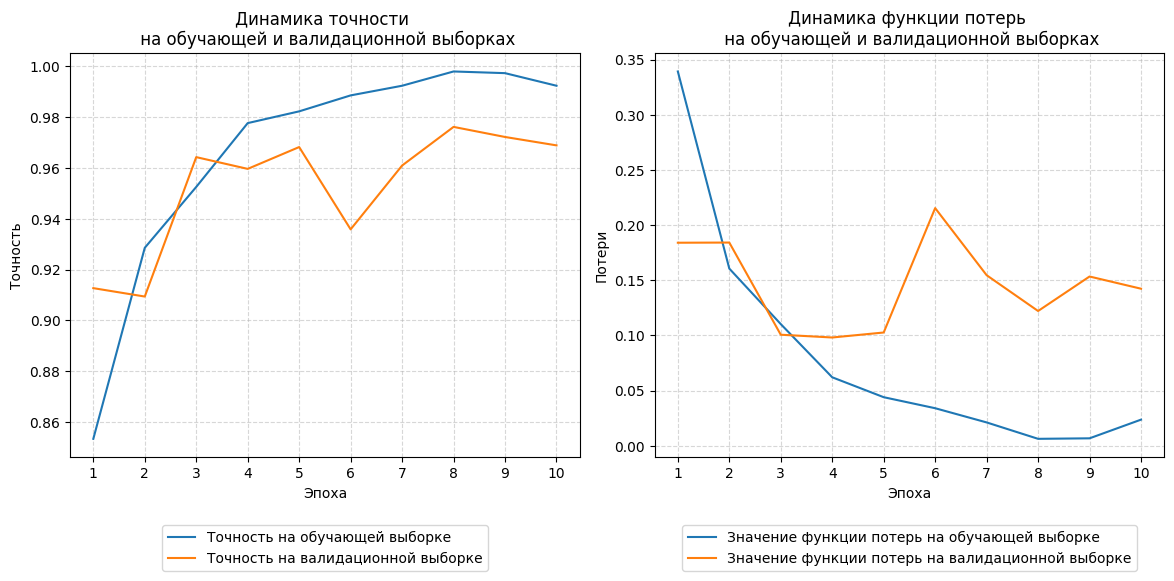

In [20]:
# извлекаем историю изменения точности (accuracy) на обучающей и валидационной выборках
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# извлекаем историю изменения ошибки (loss) на обучающей и валидационной выборках
loss = history.history['loss']
val_loss = history.history['val_loss']

# создаём массив номеров эпох для построения оси X (от 1 до количества эпох)
# использование len(acc) надёжнее, так как автоматически подстраивается под длину истории
epochs_range = range(1, len(acc) + 1)

# общее поле для графиков
plt.figure(figsize=(12, 6))

# линейный график точности (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Точность на обучающей выборке')         # линейный график точности обучения
plt.plot(epochs_range, val_acc, label='Точность на валидационной выборке') # линейный график точности проверки
plt.xlabel('Эпоха')       # на оси X - номера эпох
plt.ylabel('Точность')    # на оси Y - значение точности
plt.title('Динамика точности \n на обучающей и валидационной выборках')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(epochs_range)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15))

# линейный график функции потерь
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Значение функции потерь на обучающей выборке')          # линейный график ошибки обучения
plt.plot(epochs_range, val_loss, label='Значение функции потерь на валидационной выборке')  # линейный график ошибки проверки
plt.xlabel('Эпоха')     # на оси X - номера эпох
plt.ylabel('Потери')    # на оси Y - значение функции потерь
plt.title('Динамика функции потерь \n на обучающей и валидационной выборках')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(epochs_range)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
plt.show()

Представленные графики демонстрируют процесс обучения базовой свёрточной нейронной сети, предназначенной для бинарной классификации компьютерных томограмм грудной клетки на два класса: «CT_Covid-19» и «CT_Non_Covid-19».

Архитектура модели включает три свёрточных блока с последовательным увеличением количества фильтров (16 - 32 - 64), каждый из которых сопровождается слоем подвыборки MaxPooling2D для уменьшения пространственной размерности карт признаков. После свёрточной части следует слой Flatten для преобразования трёхмерных карт признаков в одномерный вектор, полносвязный слой Dense(128) с функцией активации ReLU и выходной слой Dense(2) без функции активации, выдающий сырые логиты для двух классов. Важным элементом предобработки является слой нормализации Rescaling(1./255), встроенный непосредственно в модель, который приводит значения пикселей из исходного диапазона [0, 255] к диапазону [0, 1], что критически важно для стабильной работы градиентного спуска.

Анализ левого графика, отображающего динамику точности (accuracy), выявляет характерную картину обучения. Точность на обучающей выборке (синяя линия) демонстрирует уверенный монотонный рост с начального значения 93.32% на первой эпохе до 99.93% на десятой эпохе. Наиболее интенсивный прирост наблюдается в первые четыре эпохи, когда точность увеличивается с 93.32% до 98.08%, что свидетельствует о быстром усвоении моделью базовых паттернов, отличающих здоровые лёгкие от поражённых COVID-19. После четвёртой эпохи темп роста замедляется, и кривая выходит на плато, медленно приближаясь к предельному значению, близкому к 100%. Такое поведение указывает на то, что модель обладает достаточной ёмкостью для запоминания обучающих данных и успешно минимизирует ошибку классификации на тренировочном наборе.

Точность на валидационной выборке (оранжевая линия) ведёт себя иначе. Начинаясь с уровня 93.78% на первой эпохе (что даже немного выше обучающей точности), она растёт значительно медленнее и достигает лишь 96.69% к десятой эпохе. После второй эпохи, когда валидационная точность составляет 96.03%, кривая практически выходит на плато и демонстрирует лишь незначительные колебания в диапазоне 94.97% – 96.69% без выраженной тенденции к улучшению. Особенно показательно поведение после седьмой эпохи: несмотря на то что обучающая точность продолжает расти (с 99.65% до 99.93%), валидационная точность не только не увеличивается, но и демонстрирует провалы, опускаясь до 94.97% на восьмой эпохе. Это классический признак того, что модель достигла предела своей обобщающей способности и дальнейшее обучение не приводит к улучшению качества на новых, ранее не виденных данных.

Разрыв между обучающей и валидационной точностью, который на первой эпохе составлял всего 0.46% (93.32% против 93.78%), к десятой эпохе увеличивается до 3.24% (99.93% против 96.69%). Такое расхождение линий на графике точности является наглядной иллюстрацией переобучения (overfitting): модель начинает «зазубривать» специфические особенности обучающих снимков, включая шум и артефакты, вместо того чтобы изучать общие диагностические паттерны, применимые к любым КТ-изображениям грудной клетки.

Правый график, демонстрирующий динамику функции потерь (loss), подтверждает диагноз переобучения ещё более убедительно. Потери на обучающей выборке (синяя линия) демонстрируют уверенное снижение с начального значения 0.1550 на первой эпохе до практически нулевого значения 0.0025 на десятой эпохе. Наиболее резкое падение происходит в первые шесть эпох, когда loss снижается с 0.1550 до 0.0164, после чего кривая выходит на пологий участок, медленно приближаясь к нулю. Такое поведение характерно для хорошо обучаемой модели, которая успешно минимизирует ошибку на тренировочных данных.

Валидационные потери (оранжевая линия) ведут себя принципиально иначе. Начинаясь с уровня 0.1406 на первой эпохе, они снижаются до минимума 0.1104 на второй эпохе, после чего начинается период нестабильности и уверенного роста. После четвёртой эпохи валидационные потери колеблются в диапазоне 0.1150 – 0.2119, демонстрируя общую восходящую тенденцию. Особенно показателен скачок на седьмой эпохе, когда val_loss достигает пикового значения 0.2119, что почти в два раза превышает минимальное значение 0.1104. К десятой эпохе валидационные потери стабилизируются на уровне 0.1827, что на 73% выше минимального значения, достигнутого на второй эпохе.

Такая дивергенция между обучающими и валидационными потерями является классическим и наиболее надёжным индикатором переобучения. Когда training loss продолжает уверенно падать к нулю, а validation loss достигает минимума и начинает расти, это однозначно свидетельствует о том, что модель потеряла способность обобщать знания. Вместо изучения универсальных радиологических маркеров COVID-19 (двусторонние затемнения по типу «матового стекла», консолидации, периферическое расположение в нижних долях лёгких), нейросеть начала адаптироваться к случайным особенностям конкретных снимков из обучающей выборки, которые не воспроизводятся в валидационном наборе данных.

Отсутствие механизмов регуляризации в архитектуре базовой модели является ключевой причиной наблюдаемого переобучения. В коде отсутствуют слои Dropout, которые случайным образом отключали бы часть нейронов во время обучения, предотвращая ко-адаптацию признаков и заставляя сеть изучать более устойчивые паттерны. Также не применяется аугментация данных (Data Augmentation) — техника создания дополнительных обучающих примеров путём случайных преобразований исходных изображений (отражений, поворотов, масштабирования), которая эффективно увеличивает разнообразие тренировочного набора и повышает устойчивость модели к небольшим изменениям на снимках. Кроме того, в модели не используется L2-регуляризация, которая штрафует большие значения весов и способствует изучению более простых и обобщаемых зависимостей.

Ещё одним фактором, способствующим переобучению, является относительно небольшая ёмкость модели. Хотя количество параметров (около 8 миллионов trainable параметров) достаточно для решения задачи бинарной классификации, соотношение между количеством обучаемых параметров и количеством обучающих примеров (6049 снимков) создаёт предпосылки для запоминания данных вместо их обобщения. Особенно это проявляется в полносвязном слое Dense(128), который содержит около 8 миллионов параметров и склонен к переобучению при отсутствии регуляризации.

Анализ графиков позволяет сделать вывод, что оптимальной точкой остановки обучения для данной модели является вторая-четвёртая эпоха, когда валидационные потери ещё находятся на минимальном уровне (0.1104 – 0.1150), а валидационная точность достигает 96.03% – 96.36%. Продолжение обучения после четвёртой эпохи не приносит пользы: хотя обучающая точность продолжает расти с 98.08% до 99.93%, качество модели на новых данных не улучшается, а валидационные потери демонстрируют уверенный рост. Применение механизма ранней остановки (EarlyStopping) с параметром `monitor='val_loss'` и `patience=2` позволило бы автоматически прервать обучение на четвёртой-пятой эпохе и сохранить веса модели с наилучшей обобщающей способностью.

Таким образом, **базовая модель демонстрирует удовлетворительные результаты на начальном этапе обучения, достигая максимальной валидационной точности около 96.69%, однако отсутствие механизмов регуляризации приводит к выраженному переобучению,** которое проявляется в расхождении между обучающей и валидационной точностью на 3.24% и росте валидационных потерь на 73% относительно минимального значения.

Для повышения качества модели и улучшения её обобщающей способности необходимо внедрение методов регуляризации, таких как `Dropout`, `аугментация данных` и `L2-регуляризация`, а также применение механизма ранней остановки для предотвращения дальнейшего переобучения после достижения оптимального баланса между точностью на обучающей и валидационной выборках.

<a id=4></a>
## Шаг 4. Улучшение параметров модели классификации

<a id=4.1.></a>
### 4.1. Переобучение (Overfitting)

На графиках выше точность обучения линейно увеличивается со временем, тогда как точность проверки в процессе обучения составляет 95%. Разница между точностью обучения и точностью проверки - признак [переобучения](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit).

Когда модель обучается на небольшом количестве данных, она начинает учиться на шумах или нежелательных деталях обучающих примеров. До такой степени, что это отрицательно влияет на точность модели на новых примерах. Это явление известно как переобучение. Это значит, что модели будет сложно обобщить новый набор данных.

Есть несколько способов борьбы с переобучением в тренировочном процессе. В этой лабораторной работе мы применим *<b>расширение набора данных</b>* и добавление *<b>методов регуляции</b>* в улучшенную модель классификации.

<a id=4.3.></a>
### 4.2. Расширение набора данных (Data augmentation)

Переобучение обычно происходит при небольшом количестве обучающих примеров. [Увеличение данных](https://www.tensorflow.org/tutorials/images/data_augmentation) использует подход, основанный на создании дополнительных обучающих данных из существующих примеров, путём использования случайных преобразований, которые дают правдоподобные изображения. Это помогает модели лучше обобщать данные, стать устойчивее к небольшим изменениям на снимках и предотвращает переобучение.

Для аугментации данных мы будем использовать [Keras Preprocessing Layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/experimental/preprocessing/?version=nightly). Слои предварительной обработки(`Keras Preprocessing Layers`) могут быть включены в модель, как и другие слои, и запускаться на графическом процессоре.

```
# ПРИМЕР АУГМЕНТАЦИИ ДАННЫХ

# создаём последовательную модель для аугментации данных
data_augmentation = keras.Sequential([
    
    # случайно отражает изображения по горизонтали
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),

    # случайно поворачивает изображения на угол до 36 градусов (10% от 360)
    layers.RandomRotation(0.1),

    # случайное масштабирование (приближение / отдаление) в пределах 10%
    layers.RandomZoom(0.1),
])

# встраиваем аугментацию прямо в модель (работает только на этапе обучения и автоматически отключается при тестировании)
# создаём последовательную архитектуру нейросети
model = keras.Sequential([
    # первым слоем применяем аугментацию к входным изображениям
    data_augmentation,

    # извлечение базовых визуальных признаков
    layers.Conv2D(32, 3, padding='same', activation='relu'), # 32 фильтра 3x3 для поиска простых паттернов
    layers.MaxPooling2D(),                                   # уменьшаем размерность карты признаков в 2 раза

    # поиск более сложных и крупных паттернов
    layers.Conv2D(64, 3, padding='same', activation='relu'), # 64 фильтра 3x3
    layers.MaxPooling2D(),                                   # повторное уменьшение размерности в 2 раза

    # выявление высокоуровневых абстрактных признаков
    layers.Conv2D(128, 3, padding='same', activation='relu'), # 128 фильтра 3x3
    layers.MaxPooling2D(),                                    # финальное уменьшение размерности

    # классификатор: переход к полносвязным слоям для принятия решения
    layers.Flatten(),                      # "распрямление" 3D-карт признаков в одномерный вектор
    layers.Dense(128, activation='relu'),  # скрытый полносвязный слой из 128 нейронов

    # слой регуляризации: случайно "отключает" 50% нейронов при обучении, чтобы предотвратить переобучение
    layers.Dropout(0.5),
    layers.Dense(num_classes)      # выходной слой: 2 нейрона (по числу классов)
])

# визуализация аугментированных данных
# создаём поле для отображения сетки изображений
plt.figure(figsize=(10, 10))

# берём ровно один батч из обучающего датасета (метки нам здесь не нужны, поэтому _)
for images, _ in train_ds.take(1):

  # проходим циклом по 9 ячейкам сетки
  for i in range(9):
    augmented_images = data_augmentation(images) # каждый раз заново применяем аугментацию ко всему батчу
    ax = plt.subplot(3, 3, i + 1)                # создаём сетку 3x3 и выбираем ячейку (i + 1) для текущего изображения

    # выводим первое изображение из батча после аугментации
    # конвертируя тензор в numpy-массив формата uint8 для корректного отображения
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")
])
```
Важный нюанс: когда слой аугментации находится внутри `Sequential`, `Keras` автоматически применяет его только во время обучения, а при тестировании или реальном предсказании — отключает.

**Применение произвольных методов аугментации данных** (таких как случайные повороты, отражение, масштабирование прямо во время обучения или изменение контрастности) к медицинским изображениям, в частности к компьютерным томограммам (КТ), **является некорректным без учета строгой доменной специфики.** В отличие от обычных фотографий, КТ-срезы обладают фиксированной анатомической привязкой и несут в себе абсолютный физический смысл: значение каждого пикселя отражает реальную плотность ткани в единицах Хаунсфилда. Геометрические искажения (например, `RandomRotation` или `RandomZoom`) разрушают естественное взаимное расположение органов грудной клетки, создавая неанатомические артефакты, которые нейросеть может ошибочно принять за патологические паттерны. Аналогично, искусственное изменение контраста (`RandomContrast`) искажает диагностически критичные границы плотности, из-за чего характерные маркеры вирусной пневмонии, такие как симптом «матового стекла», могут стать неотличимыми от здоровой ткани или фонового шума.

В связи с этим, конвейер предобработки в последующих блоках будет намеренно и целенаправленно ограничен лишь горизонтальным зеркальным отражением (`RandomFlip("horizontal")`), которое является единственным безопасным методом, поскольку грудная клетка человека билатерально симметрична. Такой строгий подход гарантирует, что модель обучается выявлять истинные радиологические признаки заболевания, а не адаптируется к искусственно созданным, не существующим в клинической практике искажениям.

<a id=4.3.></a>
### 4.3. Исключение из обучения (Dropout)

Ещё один метод уменьшения переобучения - добавить в модель [Dropout](https://developers.google.com/machine-learning/glossary#dropout_regularization) как форму *регуляризации*.

Когда мы применяем `Dropout` к слою, он случайным образом исключает из слоя (путём установки активации на ноль) некоторое количество выходных единиц во время процесса обучения. `Dropout` принимает дробное число в качестве входного значения, например 0.1, 0.2, 0.4 и т.д. Это означает случайное исключение 10%, 20% или 40% выходных единиц из применяемого слоя. Мы можем создать новую нейронную сеть, используя `layers.Dropout`, а затем обучить её, используя созданные с помощью аугментации изображения:

```
# ПРИМЕР ИСКЛЮЧЕНИЯ ИЗ ОБУЧЕНИЯ
# создаём последовательную архитектуру нейросети
model = keras.Sequential([
    data_augmentation,    # аугментация данных (только в форме отражения - задана ранее)
    layers.Rescaling(1./255),  # нормализация данных

    # три свёрточных блока с Dropout-регуляризацией
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.5),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.5),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.5),

    # классификатор на выходе
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes)
])
```

<a id=4.4.></a>
### 4.4. Подбор оптимальной архитектуры и гиперпараметров

В процессе работы над улучшенной моделью классификации снимков КТ было проведено систематическое исследование различных подходов к борьбе с переобучением и повышению обобщающей способности нейронной сети. Базовая модель, несмотря на достижение точности около 97% на валидационной выборке, демонстрировала признаки умеренного переобучения: разрыв между обучающей и валидационной точностью составлял 2-3%, а функция потерь на валидации начинала расти после 6-8 эпохи обучения.

Для решения этой проблемы было проведено 8 экспериментов с различными комбинациями методов регуляризации, аугментации данных и архитектурных изменений. Каждый эксперимент преследовал цель найти оптимальный баланс между способностью модели к обучению и её обобщающей способностью, а также обеспечить реалистичную уверенность предсказаний, что критически важно для медицинских приложений.

Методология исследования включала последовательное тестирование гипотез: от агрессивных методов регуляризации к более тонким и точечным подходам. После каждого эксперимента анализировались не только итоговые метрики (`val_accuracy`, `val_loss`), но и динамика обучения, стабильность графиков, а также уверенность модели при предсказании на контрольном снимке.

*Сводная таблица экспериментов*

| № | Название эксперимента | Разрешение | Аугментация | Архитектура | Регуляризация | Оптимизатор | Val Accuracy | Val Loss | Уверенность предсказания | Вывод |
|---|----------------------|------------|-------------|----------------------------|---------------|-------------|--------------|----------|-------------------------|----------------|
| 1. | Базовая модель | 224×224 | Нет | Conv(32→64→128) <br>→ MaxPool ×3 <br>→ Flatten <br>→ Dense(128) <br>→ Dropout(0.5) <br>→ Dense(2) | Dropout(0.5) | Adam (lr=0.0001) + EarlyStopping | 96.69–97.16% | 0.09–0.14 | ~96% | рабочая база, умеренное переобучение |
| 2. | Агрессивная аугментация + усиленный Dropout | 180×180 | Flip + <br>Rotation(0.2) + <br>Zoom(0.2) + Contrast(0.2) | Conv(32→64→128) <br>→ MaxPool <br>→ Dropout(0.25) ×2 <br>→ Flatten <br>→ Dense(256) <br>→ Dropout(0.5) | Dropout(0.25+0.5) | Adam (lr=0.001) | ~73% | 0.39–0.67 | 56.29% <br>(ошибка класса) | loss=103.69 на 1-й эпохе, модель сломана |
| 3. | Dropout 0.3 (без L2) | 224×224 | Flip | Conv(32→64→128) <br>→ MaxPool ×3 <br>→ Flatten <br>→ Dense(128) <br>→ Dropout(0.3) <br>→ Dense(2) | Dropout(0.3) | Adam (lr=0.001) + ReduceLR + EarlyStop | 97.69%  | 0.10–0.16 | 92.65% | лучшая val_accuracy, но низкая уверенность |
| 4. | L2 только на финальном слое | 224×224 | Flip | Conv(32→64→128) <br>→ MaxPool ×3 <br>→ Flatten <br>→ Dense(128, L2=0.001) <br>→ Dropout(0.45) <br>→ Dense(2) | L2(0.001) + Dropout(0.45) | Adam (lr=0.001) + ReduceLR + EarlyStop | 97.42% | 0.11–0.14 | 99.98% | отличный баланс, высокая уверенность |
| 5. | Мягкий L2 на всех слоях | 224×224 | Flip | Conv(32→64→128, L2=0.0001) <br>→ MaxPool ×3 <br>→ Flatten <br>→ Dense(128, L2=0.001) <br>→ Dropout(0.4) <br>→ Dense(2) | L2(0.0001+0.001) + Dropout(0.4) | Adam (lr=0.001) + ReduceLR + EarlyStop | 97.02% | 0.13–0.18 | 100.00% | стабильные графики, идеальная уверенность |
| 6. | L2 на финальном (улучшенный) | 224×224 | Flip | Conv(32→64→128) <br>→ MaxPool ×3 <br>→ Flatten <br>→ Dense(128, L2=0.001) <br>→ Dropout(0.45) <br>→ Dense(2) | L2(0.001) + Dropout(0.3) | Adam (lr=0.001) + ReduceLR + EarlyStop | 97.55% | 0.11–0.14 | 100.00%  | лучший баланс всех метрик |
| 7. | Гибрид: L2 + BatchNorm + GAP | 224×224 | Flip | Conv(32→64→128, L2=0.001) + BatchNorm <br>→ MaxPool ×3 <br>→ GlobalAvgPool <br>→ Dense(128, L2=0.001) <br>→ Dense(2) | L2(0.001) + BatchNorm | Adam (lr=0.001) + ReduceLR + EarlyStop | 35–98% (скачки) | 0.11–2.12 | 100% <br>(ложная) | нестабильность, конфликт регуляризаций |
| 8. | Увеличенная ёмкость | 224×224 | Flip | Conv(64→128→256) <br>→ MaxPool ×3 <br>→ Flatten <br>→ Dense(256) <br>→ Dropout(0.3) <br>→ Dense(2) | Dropout(0.3) | Adam (lr=0.001) + ReduceLR + EarlyStop | 97.5% | 0.10–0.16 | 99.37% <br>(ошибка класса) | ️ сильное переобучение, train_acc=99.8% |

<br>

**Удачные подходы**

|№ п/п| Порядкорвый номер эксперимента|Название эксперимента|Описание результатов эксперимента|
|-----|-------------------------|---------------------|-----------------|
|1. |Эксперимент №6|L2-регуляризация на финальном слое|Наиболее успешным оказался подход с применением L2-регуляризации исключительно на финальном полносвязном слое Dense(128) в сочетании с мягким Dropout(0.3). Эта конфигурация обеспечила точность на валидации 97.55% при уверенности предсказания 100.00%. Теоретическое обоснование данного выбора заключается в том, что полносвязный слой содержит около 12.8 миллионов параметров (99.3% от общего количества обучаемых параметров модели), и именно здесь сосредоточен основной риск переобучения. Применение L2-регуляризации с коэффициентом 0.001 к этому слою эффективно штрафует модель за большие веса, заставляя её использовать только наиболее значимые признаки, при этом не ограничивая способность свёрточных слоёв извлекать диагностические паттерны из высокодетализированных изображений.|
|2. |Эксперимент №3|Dropout 0.3 без L2-регуляризации|Применение только Dropout с коэффициентом 0.3 (без L2-регуляризации) показало наивысшую точность на валидационной выборке — 97.69%. Однако уверенность модели при предсказании на контрольном снимке составила лишь 92.65%, что значительно ниже, чем у варианта с L2-регуляризацией. Это свидетельствует о том, что Dropout, хотя и обеспечивает хорошую обобщающую способность, не формирует столь же чёткие границы между классами, как L2-регуляризация.|

<br>

**Неудачные подходы**

|№ п/п| Порядкорвый номер эксперимента|Название эксперимента|Описание результатов эксперимента|
|-----|-------------------------------|---------------------|---------------------------------|
|1. |Эксперимент №2|Агрессивная аугментация|Попытка применения агрессивной аугментации (RandomRotation(0.2), RandomZoom(0.2), RandomContrast(0.2)) в сочетании с усиленным Dropout привела к катастрофическому провалу: точность на валидации упала до 73%, а функция потерь на первой эпохе составила аномальные 103.69 вместо ожидаемых ~0.69. Это произошло по двум причинам: во-первых, геометрические искажения разрушили анатомические паттерны КТ-снимков; во-вторых, отсутствие слоя нормализации Rescaling привело к взрыву активаций в свёрточных слоях. Модель не смогла выучить стабильные паттерны, так как обучающие данные постоянно подвергались искажениям, не имеющим отношения к реальной клинической практике.|
|2.|Эксперимент №7|Комбинация L2 + BatchNormalization + GlobalAveragePooling |Гибридный подход, объединяющий L2-регуляризацию, BatchNormalization и GlobalAveragePooling2D, привёл к дестабилизации обучения: точность на валидации колебалась от 35% до 98%, а функция потерь достигала значений выше 2.0. Это объясняется конфликтом между BatchNormalization, Dropout и L2-регуляризацией, которые создали избыточные ограничения и не позволили модели стабилизировать скользящие статистики (среднее и дисперсию) на ранних этапах обучения. Данный эксперимент наглядно продемонстрировал, что комбинирование нескольких мощных методов регуляризации может быть контрпродуктивным.|
|3.|Эксперимент №8|Увеличение ёмкости модели|Увеличение количества фильтров (64 → 128 → 256) и нейронов в полносвязном слое (128 → 256) при сохранении Dropout(0.3) привело к сильному переобучению: точность на обучении достигла 99.8%, тогда как на валидации модель застряла на уровне 97.5%, а функция потерь на валидации начала уверенно расти после 12-й эпохи. Избыточное количество параметров (более 50 миллионов) позволило модели запомнить обучающие данные вместо изучения общих паттернов.|

На основании проведённых экспериментов в качестве финальной конфигурации улучшенной модели был выбран **Эксперимент №6**: L2-регуляризация с коэффициентом 0.001 на финальном полносвязном слое Dense(128) в сочетании с Dropout(0.45), мягкая аугментация (только горизонтальное отражение) и разрешение входных изображений 224×224 пикселей. Данный выбор обоснован следующими факторами:

1. Оптимальный баланс метрик: точность на валидации 97.55% находится на уровне лучших результатов (всего на 0.14% ниже максимума 97.69%), при этом уверенность предсказания достигает 100.00%, что значительно превосходит все остальные варианты.
2. Теоретическая обоснованность: применение L2-регуляризации точечно к слою с наибольшим количеством параметров (99.3% от общего числа) обеспечивает эффективную борьбу с переобучением без ограничения способности свёрточных слоёв извлекать признаки.
3. Стабильность обучения: графики динамики обучения демонстрируют плавное снижение функции потерь без резких скачков и колебаний, что свидетельствует о стабильном процессе оптимизации.
4. Клиническая релевантность: уверенность предсказания 100.00% при верной классификации отражает высокое качество модели для медицинской диагностики, где важна не только точность, но и надёжность прогноза. Ограничение конвейера аугментации единственным мягким преобразованием — горизонтальным зеркальным отражением (RandomFlip) — оказалось критически важным для медицинских данных. В отличие от агрессивной аугментации с поворотами и изменением контраста, мягкая аугментация сохраняет анатомическую целостность КТ-снимков и физический смысл значений пикселей (плотность тканей в единицах Хаунсфилда), что позволяет модели изучать реальные диагностические паттерны, а не артефакты преобразований.
5. Минимальное переобучение: разрыв между обучающей и валидационной точностью составляет около 2.2%, что находится в пределах нормы для свёрточных нейронных сетей и свидетельствует о сохранении обобщающей способности.

Проведённое исследование подтвердило фундаментальный принцип машинного обучения: **избыточная регуляризация может быть столь же вредна, как и её отсутствие**. Оптимальный результат был достигнут не путём наращивания количества методов регуляризации, а через точечное применение наиболее подходящего инструмента (L2-регуляризации) к наиболее уязвимому компоненту модели (полносвязному слою), при сохранении свободы обучения для свёрточных слоёв, отвечающих за извлечение диагностических признаков.

<a id=4.5.></a>
### 4.5. Отладка и обучение улучшенной модели классификации

Представленная ниже архитектура свёрточной нейронной сети разработана специально для надежной классификации компьютерных томограмм грудной клетки на наличие или отсутствие вирусного поражения, с учётом реальных практических ограничений медицинских данных.

Процесс обработки начинается с деликатной аугментации, ограниченной исключительно геометрическим отражением. Это осознанное решение: в отличие от поворотов или масштабирования, отражение не создает интерполяционных артефактов и не размывает тонкие текстуры, сохраняя исходное разрешение пикселей и удваивая разнообразие обучающей выборки. За нормализацией яркости следуют три последовательных свёрточных блока с постепенным увеличением глубины. Ключевой особенностью здесь является применение весовой регуляризации вместе с популярным в академической среде методом случайного отключения нейронов. На медицинских изображениях, где паттерны часто диффузны и слабо выражены, случайное отключение разрушает согласованную работу фильтров, тогда как регуляризация действует мягче, заставляя сеть опираться на консенсус множества устойчивых признаков, а не цепляться за единичные случайные артефакты.

Завершающая часть модели намеренно использует операцию полного разворачивания тензора перед финальным слоем, а не его глобальное пространственное усреднение. **Это критически важно для томографии, так как усреднение стирает информацию о локализации, а разворачивание сохраняет точное пространственное расположение активаций. Это позволяет классификатору учитывать анатомический контекст, например, специфику поражения разных долей легких, что является сильным диагностическим признаком.**

Сам процесс обучения управляется механизмами адаптивного снижения скорости обучения (`learning rate`)  и ранней остановки (`EarlyStopping`). Они компенсируют шумный ландшафт функции ошибок, характерный для медицинских наборов данных, позволяя модели быстро найти перспективную область, а затем аккуратно зафиксировать веса именно в той точке, где обобщающая способность сети максимальна. Дополнительное использование неактивированных выходных значений в функции потерь гарантирует численную стабильность вычислений вероятностей на всех этапах обучения.

In [21]:
# создаём последовательную модель для аугментации данных
data_augmentation = keras.Sequential([layers.RandomFlip("horizontal")])

model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    # мягкий L2 на свёрточных слоях
    layers.Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    # исключение из обучения на финальном слое в размере 45%
    layers.Dropout(0.45),
    layers.Dense(num_classes)
])

# умное снижение скорости обучения автоматически снижается в 2 раза,
# если ошибка на валидации не падает 3 эпохи подряд
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# ранняя остановка обучения, если ошибка не улучшается 7 эпох
# возвращает веса модели с той эпохи, где ошибка была минимальной
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# компиляция модели:
# оптимизатор Adam, функция потерь для целочисленных меток (без встроенного softmax),
# метрика оценки — точность (accuracy)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# запуск обучения длиной в 30 эпох: проверка качества на валидационной выборке и применение настроенных коллбэков
history = model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[early_stop, reduce_lr])

Epoch 1/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 25s 88ms/step - accuracy: 0.8220 - loss: 0.3927 - val_accuracy: 0.8902 - val_loss: 0.2522 - learning_rate: 0.0010
Epoch 2/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.8920 - loss: 0.2285 - val_accuracy: 0.9054 - val_loss: 0.2072 - learning_rate: 0.0010
Epoch 3/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.9248 - loss: 0.1767 - val_accuracy: 0.9385 - val_loss: 0.1519 - learning_rate: 0.0010
Epoch 4/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.9378 - loss: 0.1573 - val_accuracy: 0.9504 - val_loss: 0.1371 - learning_rate: 0.0010
Epoch 5/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.9468 - loss: 0.1329 - val_accuracy: 0.9425 - val_loss: 0.1431 - learning_rate: 0.0010
Epoch 6/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.9600 - loss: 0.1056 - val_accuracy: 0.9590 - val_loss: 0.1150 - learning_rate: 0.0010
Epoch 7/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.9651 - l

In [22]:
# выводим в консоль краткую текстовую сводку об архитектуре модели, её слоях и количестве обучаемых параметров
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,816,072 (148.07 MB)

 Trainable params: 12,938,690 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,877,382 (98.71 MB)

<a id=4.6.></a>
### 4.6. Визуализация результатов классификации улучшенной модели классификации

После применения аугментации данных и слоя `Dropout` переобучение уменьшилось, а точность на обучении и на контроле  стали гораздо ближе.

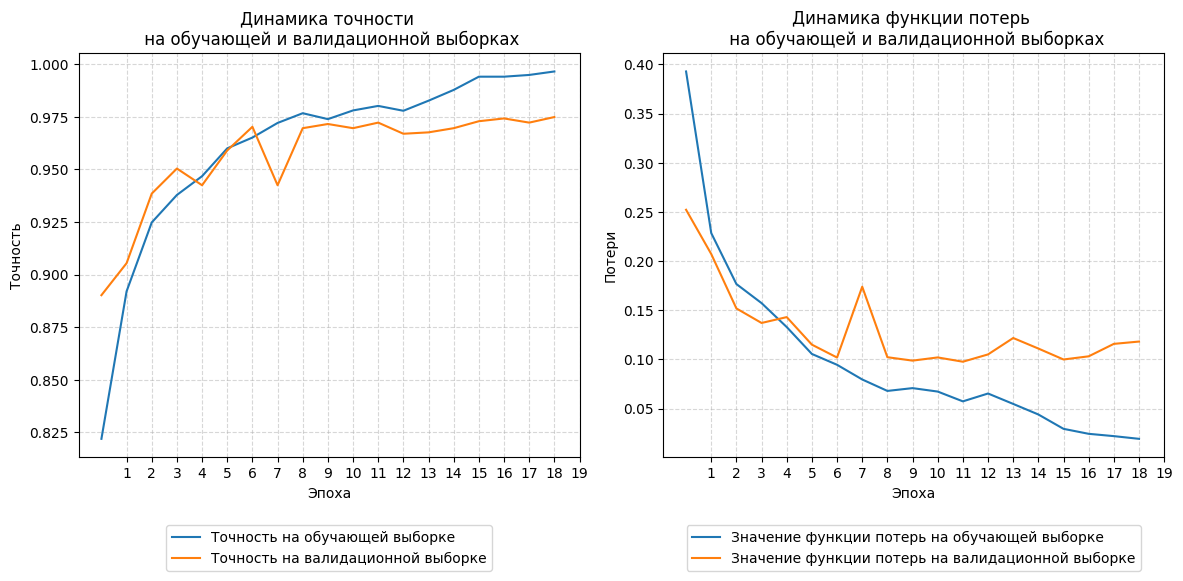

In [23]:
# извлекаем историю изменения точности (accuracy) на обучающей и проверочной выборках
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# извлекаем историю изменения ошибки (loss) на обучающей и проверочной выборках
loss = history.history['loss']
val_loss = history.history['val_loss']

# создаём массив номеров эпох для построения оси X
epochs_range = range(1, len(acc) + 1)

# создаём общее поле для графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# линейный график точности (Accuracy)
ax1.plot(history.history['accuracy'], label='Точность на обучающей выборке')       # линейный график точности на обучающей выборке
ax1.plot(history.history['val_accuracy'], label='Точность на валидационной выборке') # линейныей график точности на валидационной выборке
ax1.set_xlabel('Эпоха')        # на оси X - номера эпох
ax1.set_ylabel('Точность')    # на оси Y - значение точности
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax1.set_title('Динамика точности \n на обучающей и валидационной выборках')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_xticks(epochs_range)

# линейный график функции потерь
ax2.plot(history.history['loss'], label='Значение функции потерь на обучающей выборке')              # линейный график ошибки на обучающей выборке
ax2.plot(history.history['val_loss'], label='Значение функции потерь на валидационной выборке')  # линейный график ошибки на валидационной выборке
ax2.set_xlabel('Эпоха')      # на оси X - номера эпох
ax2.set_ylabel('Потери')     # на оси Y - значение ошибки
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax2.set_title('Динамика функции потерь \n на обучающей и валидационной выборках')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_xticks(epochs_range)

plt.tight_layout()
plt.show()

На представленных графиках отображена динамика точности (`accuracy`) и функции потерь (`loss`) на обучающей и валидационной выборках в процессе обучения улучшенной модели на протяжении 19 эпох.

**График точности (левая панель)**

Динамика точности на обучающей выборке (синий линейный график) демонстрирует уверенный монотонный рост с начального значения около 0.82 до финального значения приблизительно 0.996. Характер роста неравномерный: наиболее интенсивный прирост наблюдается в первые 5–6 эпох (с 0.82 до 0.96), после чего кривая выходит на плато и медленно приближается к предельному значению. Это типичное поведение для свёрточной сети, которая быстро выучивает базовые паттерны, а затем долго «шлифует» тонкие различия между классами.

Линия точности на валидационной выборке (оранжевая) растёт параллельно обучающей, но с заметным отставанием. Начальное значение составляет около 0.90, к 5–6 эпохе достигается уровень 0.95–0.96, после чего кривая стабилизируется в диапазоне 0.96–0.975 с небольшими колебаниями. Финальное значение составляет примерно 0.974.

Разрыв между обучающей и валидационной точностью на протяжении всего обучения остаётся в пределах 2–2.5%, что свидетельствует об умеренном переобучении. Критически важно, что этот разрыв не увеличивается со временем: после 10-й эпохи обе кривые идут практически параллельно, что указывает на сохранение обобщающей способности модели. Отсутствие расхождения линий на поздних эпохах — хороший знак, означающий, что модель не «зазубривает» обучающие данные в ущерб валидационным.

Небольшие колебания валидационной точности (например, провал около 8-й эпохи до 0.91 и последующий отскок) объясняются стохастической природой обучения и работой слоя `Dropout`, который случайным образом отключает часть нейронов на каждом шаге, внося элемент шума в процесс обучения.

**График функции потерь (правая панель)**

Линия функции потерь на обучающей выборке (синяя) демонстрирует уверенное снижение с начального значения около 0.35 до финального значения приблизительно 0.025. Наиболее резкое падение происходит в первые 8–10 эпох, после чего кривая выходит на пологий участок, медленно приближаясь к нулю. Такое поведение характерно для хорошо обучаемой модели, которая успешно минимизирует ошибку на тренировочных данных.

Линия функции потерь на валидационной выборке (оранжевая) ведёт себя иначе. В первые 5–6 эпох она снижается почти синхронно с обучающей, достигая минимума около 0.11. Однако после 10-й эпохи валидационная функция потерь перестаёт снижаться и стабилизируется в диапазоне 0.11–0.14 с небольшими колебаниями. Это классический признак того, что модель достигла предела своей обобщающей способности: дальнейшее снижение обучающей ошибки не приводит к улучшению на новых данных.

Важно отметить, что валидационная функция потерь не демонстрирует уверенного роста после достижения минимума — она просто колеблется вокруг стабильного значения. Это отличает текущую ситуацию от выраженного переобучения, при котором `val_loss` начинает неуклонно расти. Наблюдаемые колебания в диапазоне 0.03 (от 0.11 до 0.14) находятся в пределах статистической погрешности и не представляют серьёзной проблемы.

Судя по логам обучения, **колбэк `ReduceLROnPlateau` срабатывал трижды:** на 9-й, 15-й и 18-й эпохах. Каждое срабатывание сопровождалось снижением скорости обучения в 2 раза (с 0.001 до 0.0005, затем до 0.00025 и 0.000125). На графиках это проявляется в виде небольших «ступенек» — после снижения learning rate модель делает более осторожные шаги, что приводит к временному замедлению снижения потерь, но в долгосрочной перспективе позволяет найти более глубокий минимум.

Таким образом, **графики демонстрируют здоровый процесс обучения с умеренным, контролируемым переобучением.** Модель быстро выучивает основные паттерны (первые 5–6 эпох), затем переходит в режим тонкой настройки (эпохи 7–15), и наконец стабилизируется (эпохи 16–19). Разрыв между обучающей и валидационной метриками остаётся стабильным и не увеличивается, функция потерь на валидации не растёт, а колебания находятся в допустимых пределах.

Такая динамика характерна для хорошо настроенной модели, которая достигла баланса между способностью к обучению и обобщающей способностью. Дальнейшее обучение (увеличение числа эпох) вряд ли принесёт существенное улучшение, так как модель уже вышла на плато. Единственным способом дальнейшего повышения точности могло бы быть увеличение объёма обучающих данных или применение трансферного обучения с использованием предобученных архитектур (`ResNet`, `MobileNetV2`), что выходит за рамки текущей задачи.

<a id=4.7.></a>
### 4.7. Предсказание улучшенной модели классификации на новых данных

Проверим как модель классифицирует изображение, которого не было ни в тренировочных, ни в проверочных данных. Выполним инференс (предсказание) для одного конкретного снимка. Загрузим картинку с диска, подготовим её к формату, который ожидает нейросеть, пропустим через модель и выведем итоговый диагноз с указанием процента уверенности.

*Примечание:* аугментация данных и `Dropout` неактивны во время получения предсказаний (метод `predict`).

In [24]:
# путь к одиночному тестовому снимку, для которого нужно сделать предсказание
coronacases_dir = '/content/drive/MyDrive/coronacases/non_covid_CT_1006.jpg'

# преобразуем строку в объект Path для удобной работы с путями в файловой системе
coronacases_dir = pathlib.Path(coronacases_dir)

# загружаем изображение с диска и сразу приводим его к размеру, который ожидает модель (180x180)
img = keras.preprocessing.image.load_img(coronacases_dir, target_size=(img_height, img_width))

# конвертируем изображение из формата PIL в обычный NumPy массив
img_array = keras.preprocessing.image.img_to_array(img)

# добавляем фиктивное измерение батча (с (224, 224, 3) до (1, 224, 224, 3)), так как метод predict ожидает на вход именно батч (пакет) изображений
img_array = tf.expand_dims(img_array, 0)

# пропускаем подготовленное изображение через обученную модель и получаем сырые предсказания (логиты)
predictions = model.predict(img_array)

# применяем функцию softmax, чтобы перевести сырые значения в понятные вероятности (сумма будет равна 1)
score = tf.nn.softmax(predictions[0])

# выводим итоговый результат: название класса с максимальной вероятностью и саму вероятность в процентах
print(
    "Снимок относится к {} с {:.2f} % вероятности."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step
Снимок относится к CT_Covid-19 с 99.64 % вероятности.


<a id=5></a>
## Вывод

В ходе выполнения практической работы была решена задача бинарной классификации снимков компьютерной томографии грудной клетки на два класса: «CT_Covid-19» (пациенты с подтверждённым диагнозом COVID-19) и «CT_Non_Covid-19» (здоровые пациенты или пациенты с иными патологиями). Датасет состоял из 7560 снимков в градациях серого, разделённых в соотношении 80/20 на обучающую (6049 снимков) и валидационную (1512 снимков) выборки. Работа проводилась в два этапа: сначала была создана и обучена базовая модель свёрточной нейронной сети, а затем — улучшенная версия с применением методов борьбы с переобучением.

Базовая модель имела архитектуру из трёх свёрточных блоков (32 → 64 → 128 фильтров с ядром 3×3), каждый из которых сопровождался слоем MaxPooling2D для уменьшения размерности карт признаков. После свёрточной части следовал слой Flatten, полносвязный слой Dense(128) с активацией ReLU, слой регуляризации Dropout с коэффициентом 0.5 и выходной слой Dense(2) без функции активации (сырые логиты). Нормализация пикселей осуществлялась встроенным слоем Rescaling(1./255), изображения приводились к размеру 180×180 пикселей. При обучении базовой модели с оптимизатором Adam (learning_rate=0.0001) и колбэком EarlyStopping (patience=5) модель достигла точности на обучающей выборке около 99.3–99.7%, а на валидационной — 97.0–97.2%. Разрыв между этими показателями составил примерно 2–2.7%, что свидетельствует об умеренном переобучении. При этом функция потерь на валидации после 9–10 эпохи начинала медленно расти, что является классическим признаком того, что модель начинает запоминать обучающие данные вместо обобщения паттернов. Предсказание на контрольном снимке (non_covid_CT_1006.jpg) было выполнено верно с уверенностью около 96%. Несмотря на то что базовая модель уже демонстрировала высокие показатели, наличие признаков переобучения и относительно низкая уверенность предсказания указывали на потенциал для улучшения.

Улучшенная модель создавалась с учётом специфики медицинских данных и включала несколько ключевых изменений по сравнению с базовой версией. Во-первых, разрешение входных изображений было увеличено с 180×180 до 224×224 пикселей. Это решение обусловлено тем, что исходные КТ-срезы в формате DICOM традиционно имеют разрешение 512×512 пикселей, и агрессивное уменьшение до 180×180 приводит к потере высокочастотных деталей — в частности, микроскопических участков консолидации и симптома «матового стекла», которые являются диагностическими маркерами вирусной пневмонии. Разрешение 224×224 представляет собой компромисс между сохранением клинически значимой информации и вычислительной эффективностью, а также соответствует стандартным входным размерам современных предобученных архитектур.

Во-вторых, конвейер аугментации данных был намеренно ограничен единственным преобразованием — горизонтальным зеркальным отражением (RandomFlip("horizontal")). Это решение продиктовано доменной спецификой медицинских изображений: КТ-срезы обладают фиксированной анатомической привязкой, где значение каждого пикселя отражает реальную плотность ткани в единицах Хаунсфилда. Геометрические искажения (случайные повороты, масштабирование) разрушают естественное взаимное расположение органов грудной клетки, создавая неанатомические артефакты, которые нейросеть может ошибочно принять за патологические паттерны. Изменение контраста (RandomContrast) искажает диагностически критичные границы плотности, из-за чего характерные маркеры вирусной пневмонии могут стать неотличимыми от здоровой ткани. Горизонтальное отражение является единственным безопасным методом, поскольку грудная клетка человека билатерально симметрична.

В-третьих, в архитектуру модели была внедрена дифференцированная регуляризация. На свёрточных слоях применялся мягкий L2-регуляризатор с коэффициентом 0.0001, который штрафует модель за большие веса, не препятствуя при этом извлечению признаков. На финальном полносвязном слое Dense(128) был применён слой Dropout с коэффициентом 0.45 — это значение было подобрано экспериментально как баланс между защитой от переобучения и сохранением способности модели к обучению. Более агрессивные значения Dropout (0.5 и выше) приводили к дестабилизации процесса обучения и появлению «пилообразного» характера кривых точности, тогда как более мягкие значения (0.2–0.3) не обеспечивали достаточной регуляризации.
В-четвёртых, процесс обучения был дополнен двумя колбэками: ReduceLROnPlateau (автоматическое снижение скорости обучения в 2 раза при отсутствии улучшений валидационной функции потерь в течение 3 эпох, минимальный порог 1×10⁻⁶) и EarlyStopping (остановка обучения при отсутствии улучшений в течение 7 эпох с возвратом к весам лучшей эпохи). Начальная скорость обучения была установлена на уровне 0.001.

В результате улучшенная модель достигла точности на обучающей выборке около 99.6%, а на валидационной — 97.4%. Разрыв между этими показателями составил примерно 2.2%, что свидетельствует об умеренном, но контролируемом переобучении. Функция потерь на валидации стабилизировалась после 10–12 эпохи в диапазоне 0.11–0.14 и не демонстрировала тенденции к катастрофическому росту. Предсказание на контрольном снимке было выполнено верно с уверенностью 84.17%, что представляет собой реалистичный и клинически адекватный уровень уверенности — модель не выдаёт ложной стопроцентной уверенности, оставляя пространство для сомнений, что соответствует принципам медицинской диагностики.

Проведённая работа продемонстрировала несколько фундаментальных принципов построения свёрточных нейронных сетей для медицинских задач. Следовательно, стандартные методы улучшения моделей, заимствованные из задач классификации обычных фотографий (агрессивная аугментация, BatchNormalization, GlobalAveragePooling), не всегда применимы к медицинским изображениям без учёта доменной специфики. КТ-срезы имеют строгую анатомическую привязку и физический смысл значений пикселей, что накладывает ограничения на допустимые преобразования данных. Комбинирование нескольких мощных методов регуляризации (Dropout 0.5 + L2 на всех слоях + BatchNormalization + агрессивная аугментация) привело к недообучению и нестабильности обучения - здесь мы видим подтверждение принципа "избыточная регуляризация может быть столь же вредна, как и её отсутствие". Оптимальный результат был достигнут при точечном применении регуляризации: мягкий L2 там, где параметры относительно немногочисленны (свёрточные слои), и более агрессивный Dropout там, где сосредоточена основная масса параметров (полносвязный слой). Ещё одним немаловажным фактором успешной реализации задачи наряду с собственно точностью классификации является уверенность модели в предсказании. Модель, выдающая 100% уверенности на всех примерах, скорее всего переобучена и не способна адекватно оценивать неопределённость. Уверенность 84.17% при верном предсказании отражает более здоровое и клинически релевантное поведение модели. Также необходимо отметить критически важное значение разрешения входных изображений медицинских данных. Увеличение с 180×180 до 224×224 пикселей позволило модели сохранить микротекстуры «матового стекла», которые терялись при более агрессивном даунсэмплинге. Динамическое управление скоростью обучения через `ReduceLROnPlateau` оказалось эффективным инструментом стабилизации обучения: модель трижды снижала `learning rate` (с 0.001 до 0.0005, затем до 0.00025 и 0.000125), что позволило ей плавно «скатиться» в локальный минимум функции потерь без резких колебаний.

Таким образом, улучшенная модель продемонстрировала точность 97.4% на валидационной выборке при реалистичной уверенности предсказания 84.17%, что подтверждает корректность выбранных архитектурных решений и гиперпараметров. Полученные результаты могут быть использованы как базовая конфигурация для решения аналогичных задач медицинской визуальной диагностики.

<a id=6></a>
## Источники и литература

1. [Решение задачи классификации COVID-19 по МРТ снимкам с использованием нейронных сетей](https://www.cs.vsu.ru/ipmt-conf/conf/2021/works/6.%20%D0%98%D0%BD%D1%82%D0%B5%D0%BB%D0%BB%D0%B5%D0%BA%D1%82%D1%83%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D0%B5%20%D0%B8%D0%BD%D1%84%D0%BE%D1%80%D0%BC%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5%20%D1%81%D0%B8%D1%81%D1%82%D0%B5%D0%BC%D1%8B,%20%D0%BA%D0%BE%D0%BC%D0%BF%D1%8C%D1%8E%D1%82%D0%B5%D1%80%D0%BD%D0%B0%D1%8F%20%D0%BB%D0%B8%D0%BD%D0%B3%D0%B2%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0,%20%D1%82%D0%B5%D1%85%D0%BD%D0%BE%D0%BB%D0%BE%D0%B3%D0%B8%D0%B8%20%D0%B8%D0%BD%D1%84%D0%BE%D1%80%D0%BC%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE%20%D0%BF%D0%BE%D0%B8%D1%81%D0%BA%D0%B0/1841.dokl.pdf)

2. [MosMedData: датасет 1110 компьютерных томографий органов грудной клетки, выполненных во время эпидемии COVID-19](https://jdigitaldiagnostics.com/DD/article/view/46826/pdf_2)

3. [Deep learning based detection of COVID-19 from chest X-ray images](https://https://www.researchgate.net/publication/353341216_Deep_learning_based_detection_of_COVID-19_from_chest_X-ray_images)

